In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
from matplotlib import pyplot as plt 
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



In [31]:
df=pd.read_csv("nepaldata.csv")
df

,location,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
0,Chitwan,1055,1,5,4,13,4,238,1,1,0,6857500,1899000,167460,9043960
1,Dhangadi,2779,2,6,3,9,8,253,1,1,1,15284500,10004400,181760,25670660
2,Pokhara,2018,1,6,2,11,8,405,1,0,0,18162000,3632400,252600,22047000
3,Pokhara,727,4,4,4,5,3,392,1,1,1,6543000,5234400,198640,12176040
4,Pokhara,1447,4,1,4,14,6,221,1,1,1,13023000,10418400,174820,23816220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Kathmandu,1862,2,5,4,11,3,496,1,0,1,22344000,6703200,263320,29390520
996,Kathmandu,1287,4,6,4,8,4,297,1,1,1,15444000,9266400,174740,25085140
997,Pokhara,2021,1,5,1,9,4,219,1,1,1,18189000,3637800,145480,22172280
998,Chitwan,1849,3,3,3,13,5,240,1,1,0,12018500,9984600,173800,22296900


In [32]:
df.head()

,location,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
0,Chitwan,1055,1,5,4,13,4,238,1,1,0,6857500,1899000,167460,9043960
1,Dhangadi,2779,2,6,3,9,8,253,1,1,1,15284500,10004400,181760,25670660
2,Pokhara,2018,1,6,2,11,8,405,1,0,0,18162000,3632400,252600,22047000
3,Pokhara,727,4,4,4,5,3,392,1,1,1,6543000,5234400,198640,12176040
4,Pokhara,1447,4,1,4,14,6,221,1,1,1,13023000,10418400,174820,23816220


In [33]:
df.sample(5)

,location,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
323,Chitwan,1963,4,2,1,9,2,343,1,0,0,12759500,14133600,186560,27079660
318,Dhangadi,1594,1,4,2,14,5,496,1,1,0,8767000,2869200,284820,12041020
414,Kathmandu,1909,3,4,3,6,2,181,1,0,1,22908000,10308600,108020,33404620
129,Chitwan,2973,1,3,4,13,3,307,1,1,1,19324500,5351400,190940,25066840
511,Chitwan,826,4,5,1,5,6,275,1,0,1,5369000,5947200,166000,11562200


In [34]:
df.shape

(1000, 15)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   location           1000 non-null   object
 1   land_area_sqft     1000 non-null   int64 
 2   floors             1000 non-null   int64 
 3   bedrooms           1000 non-null   int64 
 4   bathrooms          1000 non-null   int64 
 5   windows            1000 non-null   int64 
 6   doors              1000 non-null   int64 
 7   cement_bags        1000 non-null   int64 
 8   rcc_structure      1000 non-null   int64 
 9   plumbing           1000 non-null   int64 
 10  electricity        1000 non-null   int64 
 11  land_cost          1000 non-null   int64 
 12  construction_cost  1000 non-null   int64 
 13  material_cost      1000 non-null   int64 
 14  total_price        1000 non-null   int64 
dtypes: int64(14), object(1)
memory usage: 117.3+ KB


In [36]:
df.columns

Index(['location', 'land_area_sqft', 'floors', 'bedrooms', 'bathrooms',
       'windows', 'doors', 'cement_bags', 'rcc_structure', 'plumbing',
       'electricity', 'land_cost', 'construction_cost', 'material_cost',
       'total_price'],
      dtype='object')

In [37]:
df.describe()

,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.0,1000.00000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03
mean,1783.32400,2.517000,3.467000,2.482000,9.005000,5.12900,338.425000,1.0,0.49000,0.504000,1.330775e+07,8.040146e+06,201865.500000,2.164888e+07
std,696.19825,1.130924,1.716933,1.104036,3.202691,1.99558,91.084185,0.0,0.50015,0.500234,7.686120e+06,4.908555e+06,41585.304381,1.080656e+07
min,606.00000,1.000000,1.000000,1.000000,4.000000,2.00000,180.000000,1.0,0.00000,0.000000,2.428000e+06,1.092600e+06,107040.000000,3.876860e+06
25%,1184.75000,1.000000,2.000000,2.000000,6.000000,3.00000,259.750000,1.0,0.00000,0.000000,7.396750e+06,4.043250e+06,169005.000000,1.301385e+07
50%,1780.00000,3.000000,3.000000,2.000000,9.000000,5.00000,336.500000,1.0,0.00000,1.000000,1.122000e+07,7.027200e+06,201590.000000,2.003528e+07
75%,2381.50000,4.000000,5.000000,3.000000,12.000000,7.00000,416.000000,1.0,1.00000,1.000000,1.755975e+07,1.099575e+07,234900.000000,2.844340e+07
max,3000.00000,4.000000,6.000000,4.000000,14.000000,8.00000,500.000000,1.0,1.00000,1.000000,3.583200e+07,2.142000e+07,293480.000000,5.736834e+07


In [38]:
df.isnull().sum()

location             0
land_area_sqft       0
floors               0
bedrooms             0
bathrooms            0
windows              0
doors                0
cement_bags          0
rcc_structure        0
plumbing             0
electricity          0
land_cost            0
construction_cost    0
material_cost        0
total_price          0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(0)

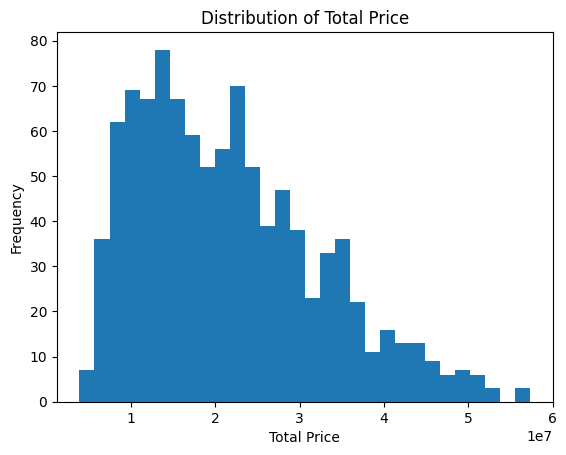

In [53]:
plt.hist(df['total_price'], bins=30)
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.title('Distribution of Total Price')
plt.show()


<Axes: >

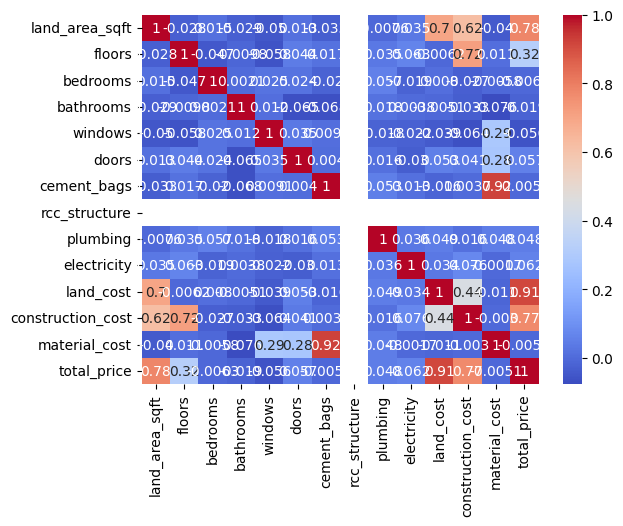

In [58]:
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')


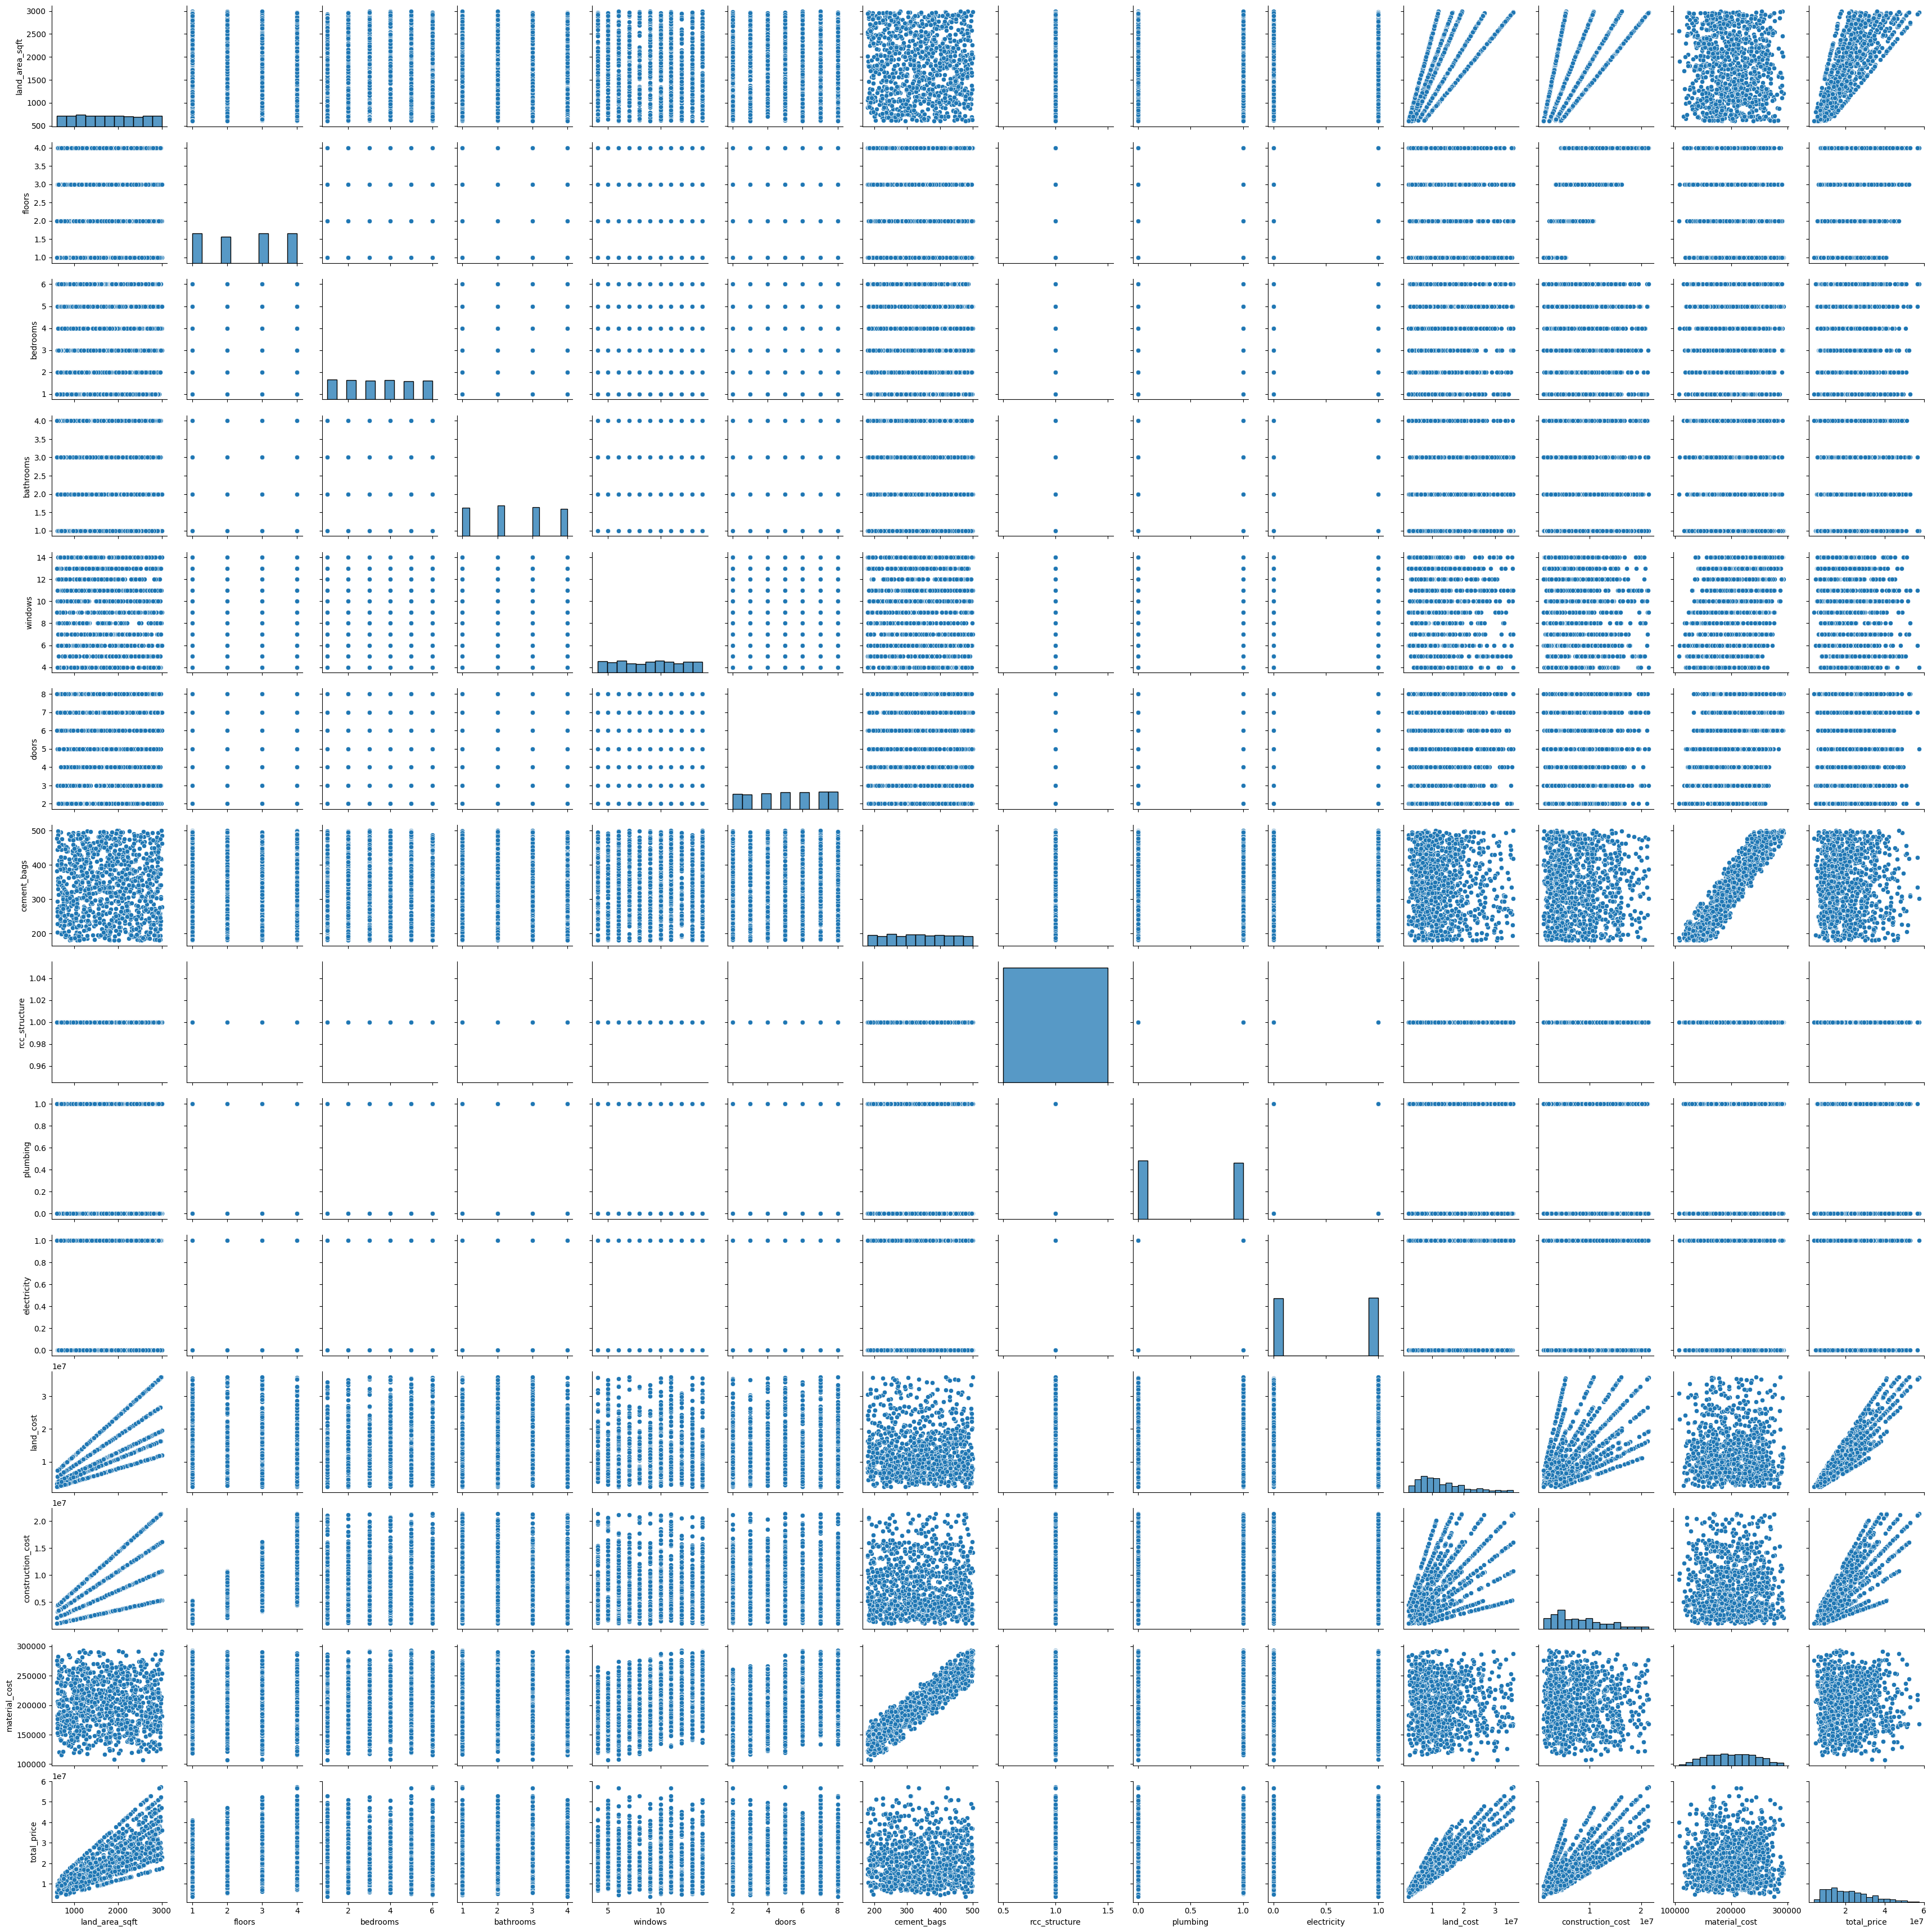

In [60]:
df.corr(numeric_only=True)
sns.pairplot(df)

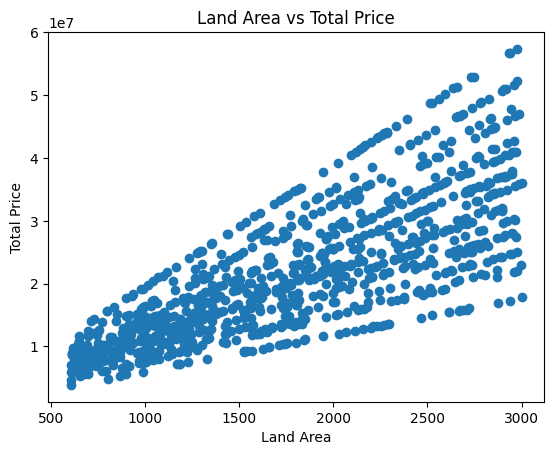

In [61]:
plt.scatter(df['land_area_sqft'], df['total_price'])
plt.xlabel('Land Area')
plt.ylabel('Total Price')
plt.title('Land Area vs Total Price')
plt.show()


In [63]:
df.corr(numeric_only=True)

,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
land_area_sqft,1.000000,-0.027815,0.015023,-0.028913,-0.049505,0.013286,-0.033089,NaN,-0.007643,0.035206,0.700337,0.618284,-0.040277,0.778882
floors,-0.027815,1.000000,-0.046623,-0.009776,-0.057922,0.043603,0.016931,NaN,0.034810,0.062694,-0.006201,0.716903,0.011470,0.321691
bedrooms,0.015023,-0.046623,1.000000,0.002063,0.024696,0.023593,-0.020345,NaN,0.057317,-0.019077,0.008001,-0.026795,-0.005832,-0.006255
bathrooms,-0.028913,-0.009776,0.002063,1.000000,0.011774,-0.064597,-0.067638,NaN,0.017802,0.003756,-0.005095,-0.032767,-0.076097,-0.018688
windows,-0.049505,-0.057922,0.024696,0.011774,1.000000,0.034825,0.009076,NaN,-0.018404,-0.022193,-0.038540,-0.064226,0.287093,-0.055664
doors,0.013286,0.043603,0.023593,-0.064597,0.034825,1.000000,0.004043,NaN,0.015836,-0.030098,0.052929,0.041259,0.277039,0.057429
cement_bags,-0.033089,0.016931,-0.020345,-0.067638,0.009076,0.004043,1.000000,NaN,0.053191,0.013243,-0.015834,0.003725,0.923438,-0.005672
rcc_structure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plumbing,-0.007643,0.034810,0.057317,0.017802,-0.018404,0.015836,0.053191,NaN,1.000000,0.036168,0.048861,0.015867,0.048151,0.047833
electricity,0.035206,0.062694,-0.019077,0.003756,-0.022193,-0.030098,0.013243,NaN,0.036168,1.000000,0.033788,0.075847,-0.001743,0.062380


In [44]:
df.dtypes

location             object
land_area_sqft        int64
floors                int64
bedrooms              int64
bathrooms             int64
windows               int64
doors                 int64
cement_bags           int64
rcc_structure         int64
plumbing              int64
electricity           int64
land_cost             int64
construction_cost     int64
material_cost         int64
total_price           int64
dtype: object

In [65]:
X = df.drop('total_price', axis=1)
y = df['total_price']
X = pd.get_dummies(X, columns=['location'], drop_first=True)


In [69]:
X.head()

,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,location_Dhangadi,location_Kathmandu,location_Pokhara,location_Syangja
0,1055,1,5,4,13,4,238,1,1,0,6857500,1899000,167460,False,False,False,False
1,2779,2,6,3,9,8,253,1,1,1,15284500,10004400,181760,True,False,False,False
2,2018,1,6,2,11,8,405,1,0,0,18162000,3632400,252600,False,False,True,False
3,727,4,4,4,5,3,392,1,1,1,6543000,5234400,198640,False,False,True,False
4,1447,4,1,4,14,6,221,1,1,1,13023000,10418400,174820,False,False,True,False


In [66]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))


Train Score: 1.0
Test Score: 1.0


Linear Regression can perfectly predict total_price because it is directly derived from cost columns.

For real predictive modeling, features like land_area_sqft, bedrooms, bathrooms, and location are more realistic predictors, while cost columns may be excluded.

Outliers may need handling if dataset is expanded.

Feature scaling was not required because Linear Regression is robust to large numeric ranges in this case.